# 01 — Data Loading, EDA & Preprocessing

**Goal of this notebook:** load a real tabular dataset, understand it, clean it, and split it in a way
that lets us run a *fair, controlled* comparison later. This is the foundation every other notebook
depends on — every model in this project will be trained/evaluated on the exact splits created here.

**Dataset:** UCI *Adult Census Income* dataset (via `sklearn.datasets.fetch_openml`). ~48,800 rows,
binary classification target: does a person earn `>50K` or `<=50K` per year, based on features like
age, education, occupation, hours worked, etc. It's large enough to build a **small / medium / large**
training-set experiment, which is the core idea of this whole project.

**Why this matters for the project:** we deliberately keep the validation and test sets *fixed* and
only vary the *training set size*. That's what makes "classical ML vs deep learning at different data
sizes" a real, controlled experiment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../results", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

## 1. Load the data

`fetch_openml` downloads the dataset and caches it
locally afterwards. If the download is slow/blocked, an alternative is to download the CSV manually
from https://archive.ics.uci.edu/dataset/2/adult and load it with `pd.read_csv`.

In [2]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [4]:
TARGET = "class"
print(df[TARGET].value_counts())

class
<=50K    37155
>50K     11687
Name: count, dtype: int64


## 2. Basic exploration

We look at: data types, missing values, and class balance. Class balance matters a lot — if the
dataset is heavily imbalanced, accuracy alone becomes a misleading metric, which is why we'll also
report F1 and ROC-AUC in every experiment.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [6]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

occupation        2809
workclass         2799
native-country     857
dtype: int64


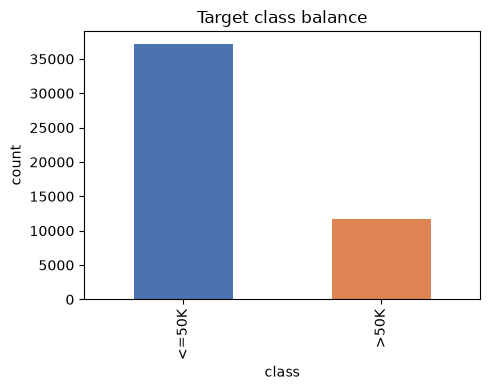

In [7]:
# Class balance plot
plt.figure(figsize=(5,4))
df[TARGET].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Target class balance")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("../results/figures/class_balance.png", dpi=150)
plt.show()

In [8]:
# Split columns into numeric vs categorical — we'll preprocess them differently
numeric_cols = df.drop(columns=[TARGET]).select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.drop(columns=[TARGET]).select_dtypes(include=["category", "object"]).columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


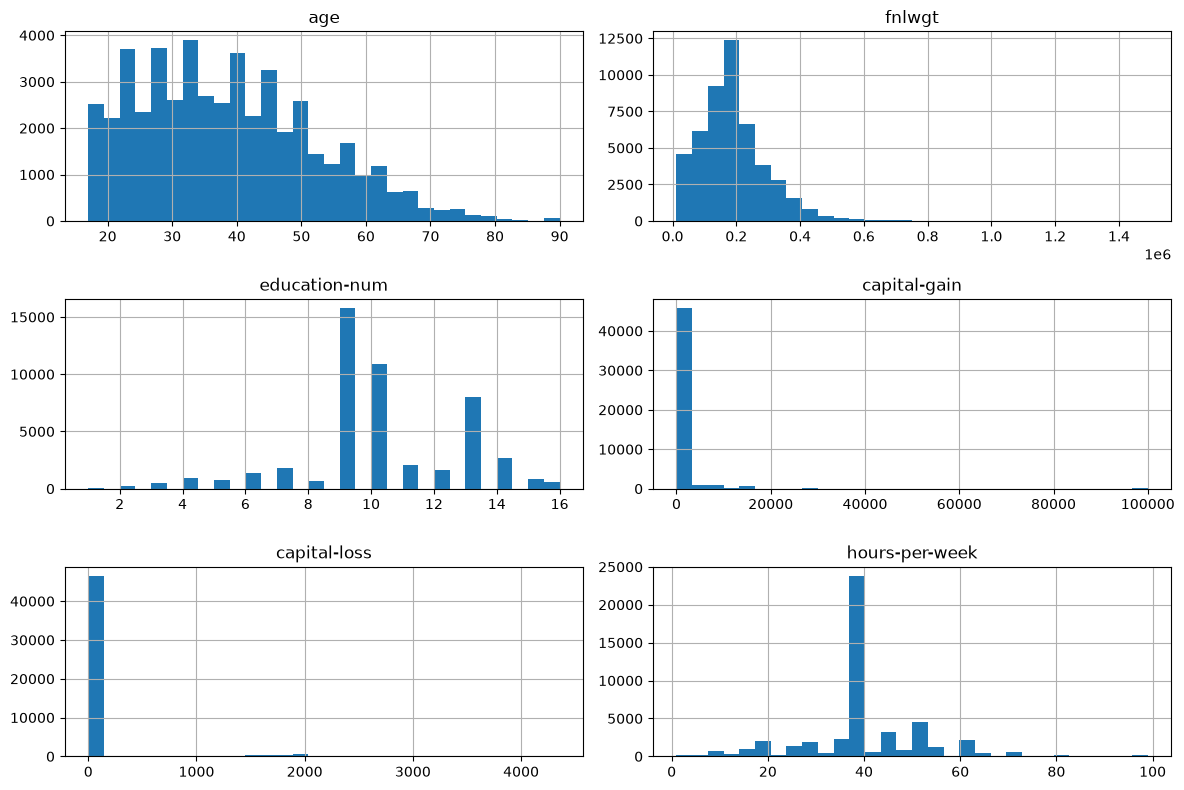

In [9]:
# Quick look at numeric feature distributions
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.savefig("../results/figures/numeric_histograms.png", dpi=150)
plt.show()

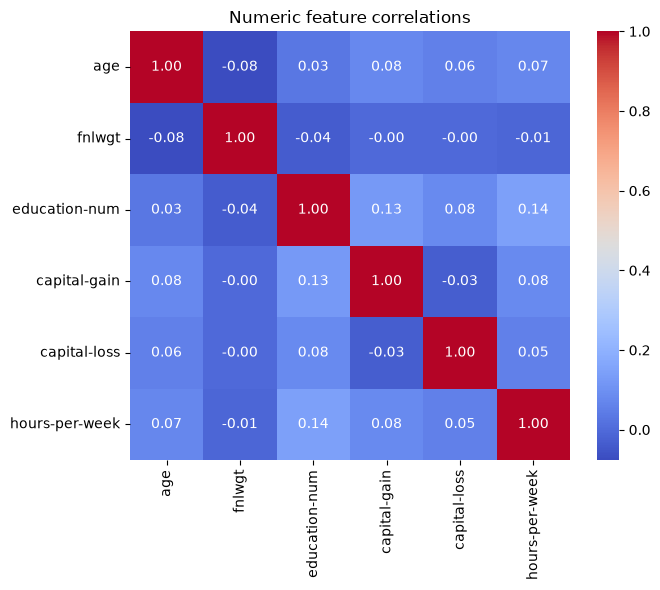

In [10]:
# Correlation heatmap among numeric features
plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.savefig("../results/figures/correlation_heatmap.png", dpi=150)
plt.show()

## 3. Train / Validation / Test split

We split **once**, here, and every
notebook after this reuses the exact same validation and test sets. That's the only way "small vs
medium vs large training set" comparisons stay fair — every model, no matter its training set size,
is judged on the same unseen data.

Split ratio: 70% train pool / 15% validation / 15% test, **stratified** on the target so class balance
is preserved in every split.

In [11]:
X = df.drop(columns=[TARGET])
y = (df[TARGET] == ">50K").astype(int)   # convert to 0/1

# First split off the test set
X_trainpool, X_test, y_trainpool, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
# Then split the remaining pool into train / validation
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_trainpool, y_trainpool, test_size=0.1765, stratify=y_trainpool, random_state=RANDOM_STATE
)  # 0.1765 * 0.85 ≈ 0.15 of the original data -> ~70/15/15 overall

print("Train pool:", X_train_full.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train pool: (34187, 14)  Val: (7328, 14)  Test: (7327, 14)


## 4. Preprocessing pipeline

We build a `ColumnTransformer` that:
- One-hot encodes categorical columns
- Standardizes (zero mean, unit variance) numeric columns

**Critical rule:** we `fit` the transformer ONLY on the training data, then `transform` (not fit) the
validation and test sets. Fitting on the full dataset would leak information from val/test into
training

In [12]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

preprocessor.fit(X_train_full)

X_train_full_proc = preprocessor.transform(X_train_full)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Some sklearn versions return sparse matrices from OneHotEncoder — densify for our purposes
if hasattr(X_train_full_proc, "toarray"):
    X_train_full_proc = X_train_full_proc.toarray()
    X_val_proc = X_val_proc.toarray()
    X_test_proc = X_test_proc.toarray()

print(X_train_full_proc.shape, X_val_proc.shape, X_test_proc.shape)

(34187, 108) (7328, 108) (7327, 108)


## 5. Create small / medium / large training subsets

We carve **three nested subsets** out of the same
training pool:

- **small**  ≈ 800 rows   — simulates a low-data / early-stage-project scenario
- **medium** ≈ 6,000 rows — a "reasonable amount of data" scenario
- **large**  = all the rows (34187) — a "data-rich" scenario

All three are drawn with **stratified sampling** so the class balance stays the same in every subset.
Validation and test sets never change — only training size changes. That single design choice is what
lets us later plot "accuracy vs. training set size" and get a meaningful, honest answer.

In [13]:
def stratified_subsample(X, y, n, random_state=RANDOM_STATE):
    idx_pos = np.where(y.values == 1)[0]
    idx_neg = np.where(y.values == 0)[0]
    pos_frac = len(idx_pos) / len(y)
    n_pos = int(round(n * pos_frac))
    n_neg = n - n_pos
    rng = np.random.RandomState(random_state)
    chosen_pos = rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False)
    chosen_neg = rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False)
    chosen = np.concatenate([chosen_pos, chosen_neg])
    rng.shuffle(chosen)
    return X[chosen], y.values[chosen]

SIZES = {"small": 800, "medium": 6000, "large": X_train_full_proc.shape[0]}

subsets = {}
for name, n in SIZES.items():
    Xs, ys = stratified_subsample(X_train_full_proc, y_train_full, n)
    subsets[name] = (Xs, ys)
    print(f"{name}: {Xs.shape[0]} rows, positive rate = {ys.mean():.3f}")

small: 800 rows, positive rate = 0.239
medium: 6000 rows, positive rate = 0.239
large: 34187 rows, positive rate = 0.239


## 6. Save everything for the other notebooks

We save the processed arrays with `joblib` so every later notebook can just load them instead of
repeating this preprocessing (and, importantly, so every notebook uses *identical* data).

In [14]:
joblib.dump({
    "subsets": subsets,                 # dict: name -> (X_train, y_train)
    "X_val": X_val_proc, "y_val": y_val.values,
    "X_test": X_test_proc, "y_test": y_test.values,
    "preprocessor": preprocessor,
    "feature_names_numeric": numeric_cols,
    "feature_names_categorical": categorical_cols,
}, "../data/processed/tabular_data.joblib")

print("Saved processed data to ../data/processed/tabular_data.joblib")

Saved processed data to ../data/processed/tabular_data.joblib


## Summary

We now have a cleanly preprocessed dataset split into fixed validation/test sets, plus three
stratified training subsets (small/medium/large) that every model in this project will be trained and
compared on.